# Character-Level Text Generation using Simple RNN

This notebook documents the cleaned portfolio workflow for character-level next-character prediction. It uses the same modular code as the Streamlit app and loads the included pre-trained model by default.

> **Responsible use:** Generated text may be repetitive, inaccurate, biased, or nonsensical. This project is educational and requires human review.

## 1. Project setup

The original project used one-hot tensors and trained inside the Streamlit interface. This version uses integer sequences, an embedding layer, a chronological validation split, saved artifacts, and a separate inference app.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("Run this notebook from the project root or notebooks folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_preprocessing import load_text_corpus, chronological_text_split
from src.text_preprocessing import CharacterVocabulary
from src.sequence_generation import build_train_validation_sequences
from src.model_training import CharacterSimpleRNN, TrainingConfig, train_model
from src.model_evaluation import build_markov_model, generate_markov_text, generated_text_metrics
from src.text_generator import load_generation_bundle, generate_text

PROJECT_ROOT

PosixPath('/mnt/data/Simple_RNN/Text_Generation')

## 2. Load and inspect the public-domain corpus

In [2]:
CORPUS_PATH = PROJECT_ROOT / "data" / "sample_text.txt"
corpus = load_text_corpus(CORPUS_PATH)
print(f"Corpus characters: {len(corpus):,}")
print(f"Corpus lines: {corpus.count(chr(10)) + 1:,}")
print(corpus[:800])

Corpus characters: 45,382
Corpus lines: 879
CHAPTER I.
Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure of
making a daisy-chain would be worth the trouble of getting up and
picking the daisies, when suddenly a White Rabbit with pink eyes ran
close by her.

There was nothing so _very_ remarkable in that; nor did Alice think it
so _very_ much out of the way to hear the Rabbit say to itself, “Oh
dear! Oh dear! I shall be late!” 


The preprocessing pipeline preserves capitalization, punctuation, quotation marks, and paragraph boundaries. These features are useful signals for character-level generation.

## 3. Chronological split and vocabulary

In [3]:
split = chronological_text_split(corpus, validation_fraction=0.10)
vocabulary = CharacterVocabulary.fit(split.train_text)

summary = {
    "training_characters": len(split.train_text),
    "validation_characters": len(split.validation_text),
    "vocabulary_size": vocabulary.size,
}
pd.DataFrame([summary])

,training_characters,validation_characters,vocabulary_size
0,40843,4539,71


The split happens **before** overlapping sequence windows are created. This avoids near-duplicate windows leaking across training and validation data.

## 4. Create next-character training pairs

In [4]:
SEQUENCE_LENGTH = 50
STEP = 3

dataset = build_train_validation_sequences(
    corpus,
    sequence_length=SEQUENCE_LENGTH,
    step=STEP,
    validation_fraction=0.10,
)

sequence_summary = pd.DataFrame([
    {
        "training_sequences": len(dataset.X_train),
        "validation_sequences": len(dataset.X_validation),
        "sequence_length": SEQUENCE_LENGTH,
        "vocabulary_size": dataset.vocabulary.size,
        "input_dtype": str(dataset.X_train.dtype),
    }
])
sequence_summary

,training_sequences,validation_sequences,sequence_length,vocabulary_size,input_dtype
0,13598,1497,50,71,int32


In [5]:
example_index = 10
input_text = dataset.vocabulary.decode(dataset.X_train[example_index])
target_character = dataset.vocabulary.decode([dataset.y_train[example_index]])
print("Input sequence:", repr(input_text))
print("Target character:", repr(target_character))

Input sequence: 'e\n\nAlice was beginning to get very tired of sittin'
Target character: 'g'


## 5. Simple RNN architecture

In [6]:
config = TrainingConfig(
    sequence_length=SEQUENCE_LENGTH,
    step=STEP,
    embedding_dim=32,
    rnn_units=64,
    dropout_rate=0.20,
    epochs=18,
)

model_preview = CharacterSimpleRNN(
    vocabulary_size=dataset.vocabulary.size,
    embedding_dim=config.embedding_dim,
    rnn_units=config.rnn_units,
    dropout_rate=config.dropout_rate,
)
model_preview

CharacterSimpleRNN(
  (embedding): Embedding(71, 32)
  (rnn): RNN(32, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=64, out_features=71, bias=True)
)

Architecture:

```text
Character IDs → Embedding → Simple RNN → Dropout → Vocabulary logits
```

Cross-entropy loss trains the model to assign high probability to the correct next character.

## 6. Optional model training

In [7]:
RUN_TRAINING = False

if RUN_TRAINING:
    trained_model, history_df, model_path = train_model(
        dataset,
        config=config,
        model_dir=PROJECT_ROOT / "models",
    )
    display(history_df.tail())
    print("Saved:", model_path)
else:
    print("Using the included pre-trained model. Set RUN_TRAINING=True to retrain.")

Using the included pre-trained model. Set RUN_TRAINING=True to retrain.


## 7. Load saved artifacts and inspect metrics

In [8]:
bundle = load_generation_bundle(PROJECT_ROOT / "models")
metadata = bundle.metadata
pd.DataFrame([
    {
        "model_type": metadata["model_type"],
        "sequence_length": metadata["sequence_length"],
        "vocabulary_size": metadata["vocabulary_size"],
        "validation_loss": metadata["validation_loss"],
        "validation_accuracy": metadata["validation_accuracy"],
        "validation_perplexity": metadata["validation_perplexity"],
    }
])

,model_type,sequence_length,vocabulary_size,validation_loss,validation_accuracy,validation_perplexity
0,PyTorch nn.RNN (Simple RNN),50,71,1.95429,0.440882,7.058908


## 8. Generate text at multiple temperatures

In [9]:
seed = "Alice was beginning"
rows = []
for temperature in [0.3, 0.7, 1.0, 1.2]:
    generated = generate_text(
        bundle,
        seed_text=seed,
        generation_length=250,
        temperature=temperature,
        top_k=20,
        random_seed=42,
    )
    rows.append({
        "temperature": temperature,
        **generated_text_metrics(generated),
        "generated_text": generated,
    })

temperature_df = pd.DataFrame(rows)
temperature_df[["temperature", "unique_trigram_ratio", "repeated_trigram_ratio", "generated_text"]]

,temperature,unique_trigram_ratio,repeated_trigram_ratio,generated_text
0,0.3,0.307116,0.692884,Alice was beginning to and and the was she was...
1,0.7,0.696629,0.303371,Alice was beginning mosered is she sat shitg o...
2,1.0,0.853933,0.146067,Alice was beginning it aver inthen of snever i...
3,1.2,0.917603,0.082397,"Alice was beginning, wicusp intire matlo.”,, f..."


Lower temperatures favor the most likely characters and tend to repeat. Higher temperatures increase diversity but also increase spelling and grammar errors.

## 9. Compare with a Markov baseline

In [10]:
markov_model = build_markov_model(corpus, order=3)
markov_sample = generate_markov_text(
    markov_model,
    seed_text=seed,
    generation_length=250,
    random_seed=42,
)
rnn_sample = temperature_df.loc[temperature_df["temperature"] == 0.7, "generated_text"].iloc[0]

comparison = pd.DataFrame([
    {"model": "3-character Markov", **generated_text_metrics(markov_sample), "sample": markov_sample},
    {"model": "Simple RNN", **generated_text_metrics(rnn_sample), "sample": rnn_sample},
])
comparison[["model", "unique_trigram_ratio", "repeated_trigram_ratio", "sample"]]

,model,unique_trigram_ratio,repeated_trigram_ratio,sample
0,3-character Markov,0.857678,0.142322,"Alice was beginning!” said go dow,” said pebbl..."
1,Simple RNN,0.696629,0.303371,Alice was beginning mosered is she sat shitg o...


## 10. Review saved visualizations

training_curve.png


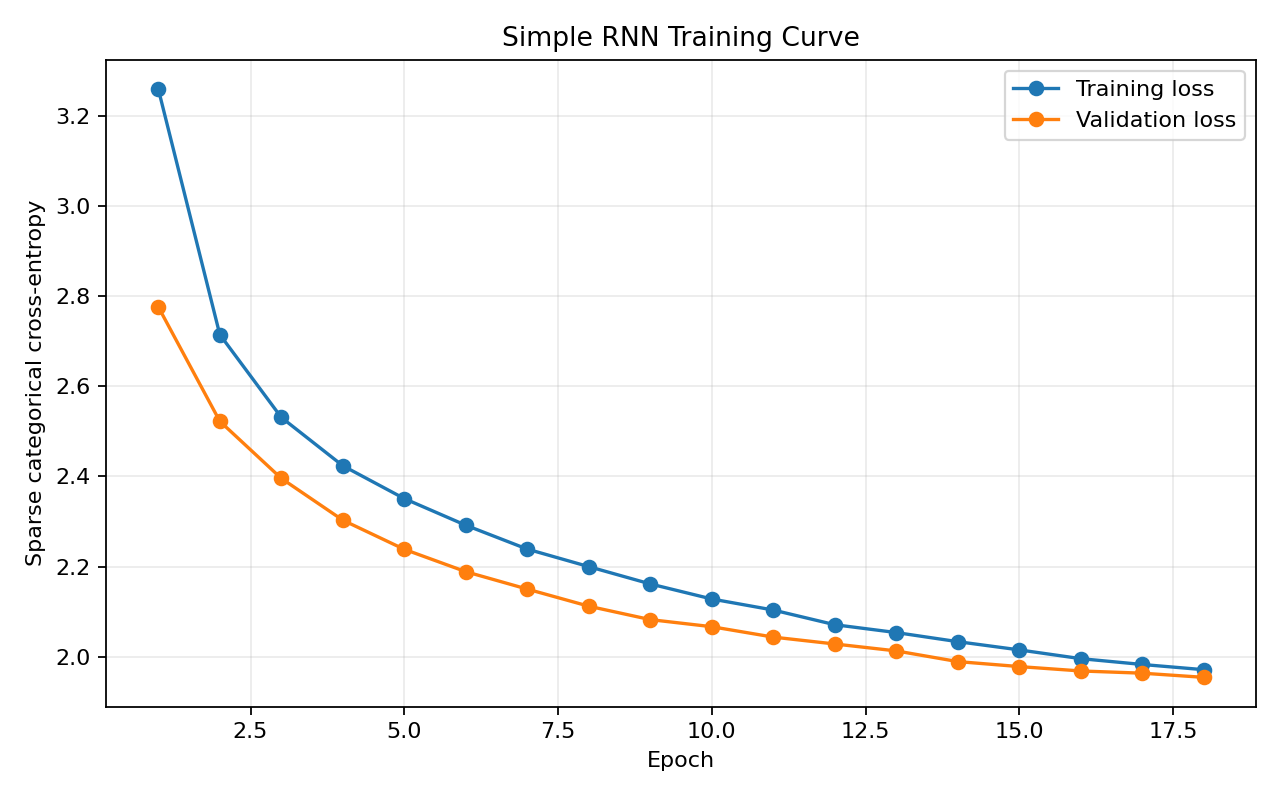

temperature_comparison.png


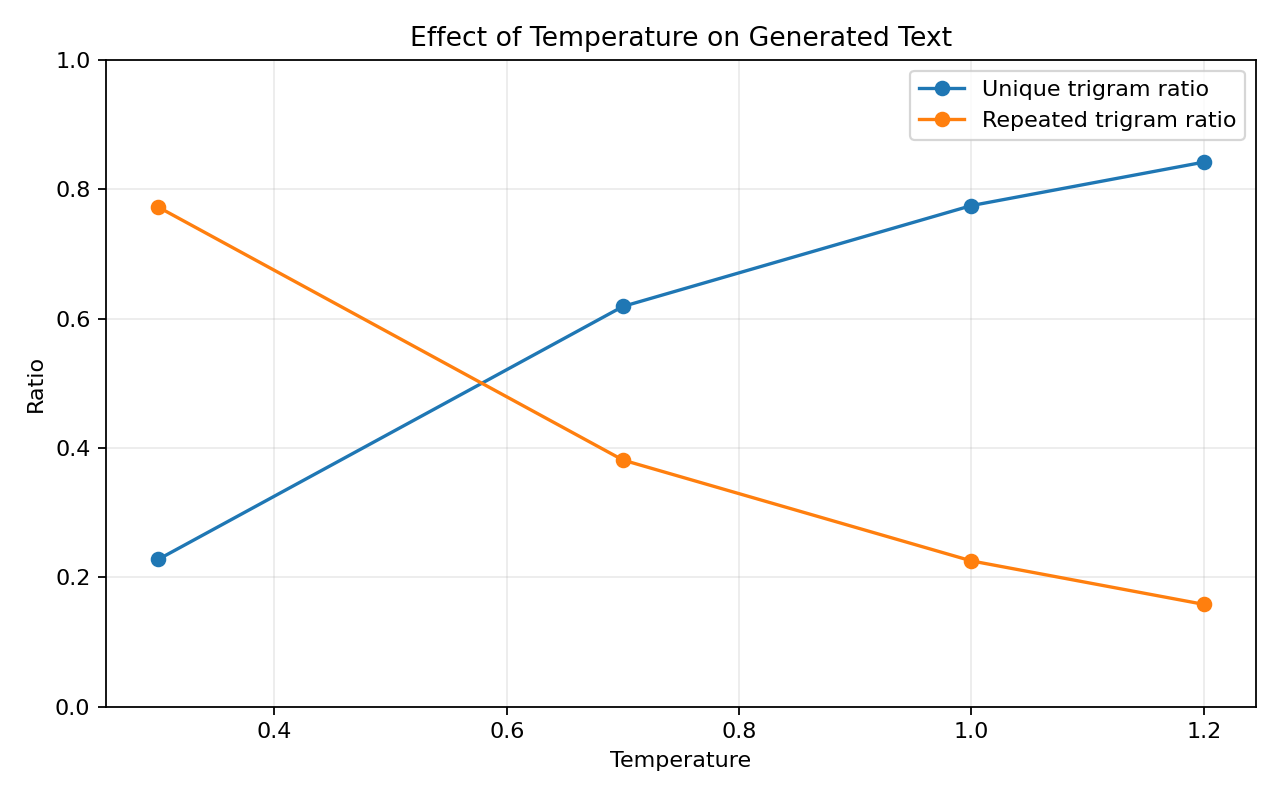

sequence_length_summary.png


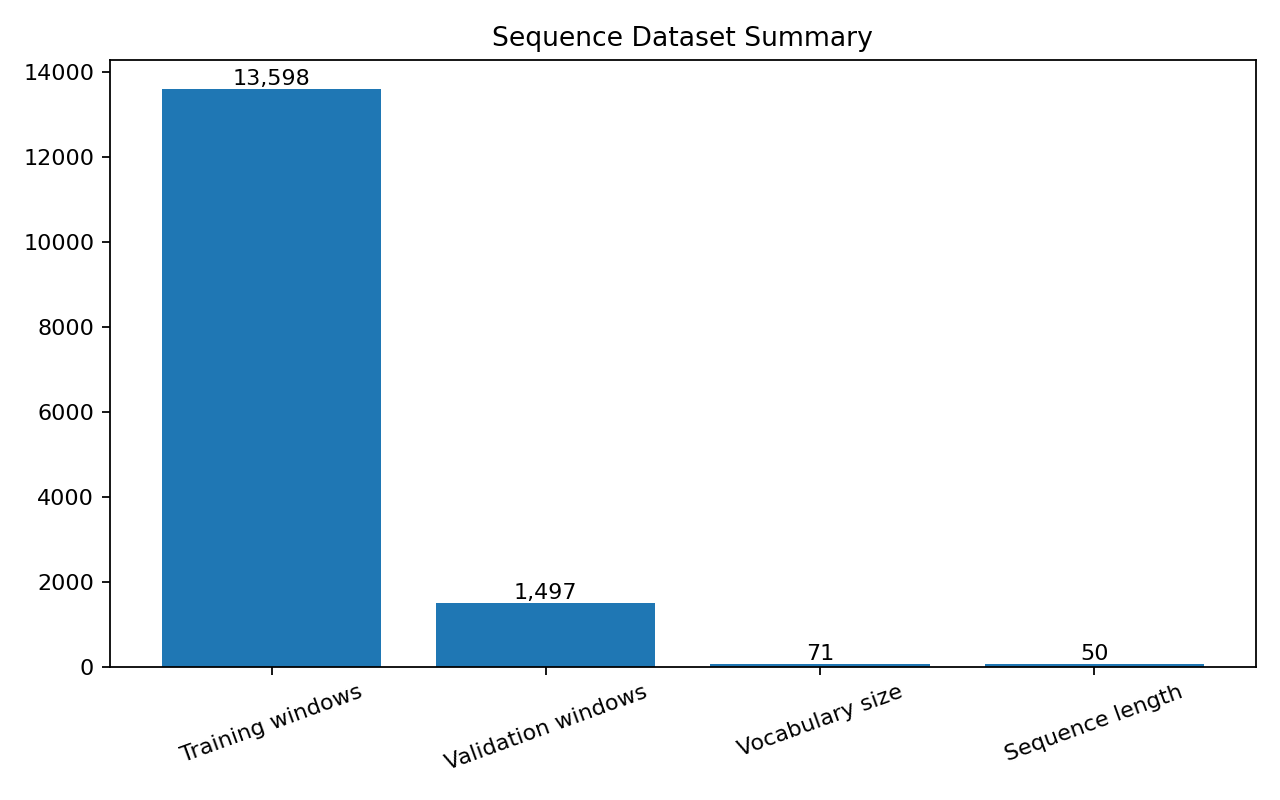

In [11]:
for filename in [
    "training_curve.png",
    "temperature_comparison.png",
    "sequence_length_summary.png",
]:
    path = PROJECT_ROOT / "outputs" / filename
    print(filename)
    display(Image(filename=str(path)))

## 11. Conclusions

- The project is a character-level next-character prediction system.
- A chronological split reduces leakage from overlapping windows.
- Integer encoding plus an embedding layer is more memory-efficient than one-hot input tensors.
- The Simple RNN learns useful local structure, but generated text remains imperfect.
- Temperature and top-k materially change generation behavior.
- The deployed Streamlit app loads the saved checkpoint and never retrains during inference.

The limitations are part of the portfolio story: this project demonstrates why LSTM, GRU, and Transformer architectures were developed to handle longer dependencies more effectively.